In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Superstore.csv",encoding="latin1")
print(df.shape)




(9994, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [7]:
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [ ]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [4]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

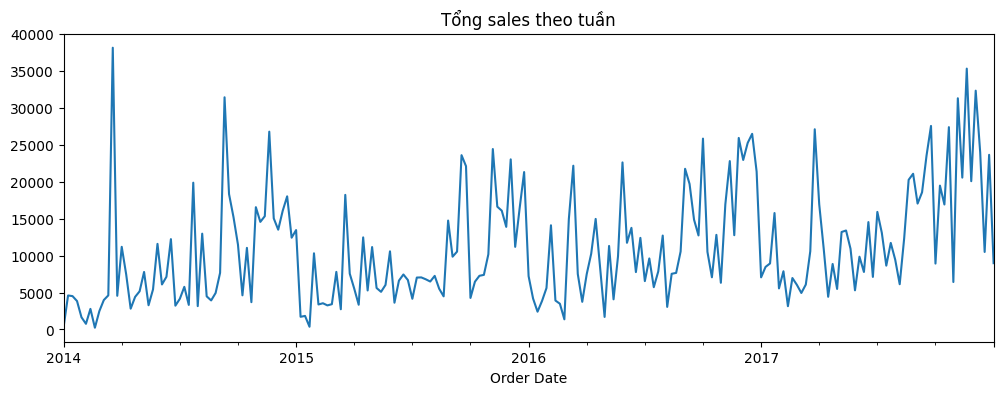

In [22]:
#gộp theo ngày
daily_sales = df.groupby('Order Date')['Sales'].sum()

#gộp theo tuần
weekly_sales = daily_sales.resample('W').sum()
weekly_sales.plot(figsize = (12,4), title ='Tổng sales theo tuần')
plt.show()

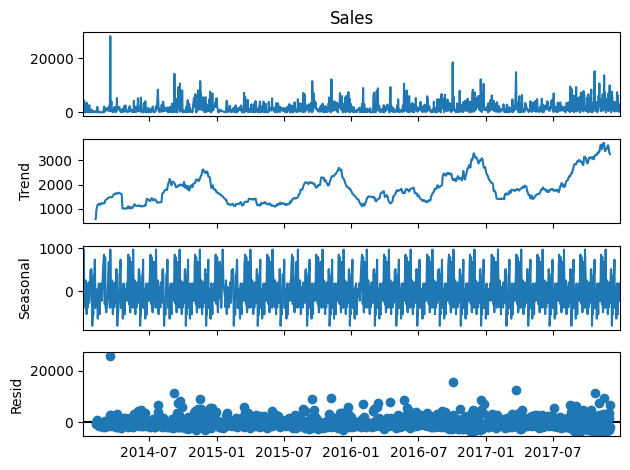

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(daily_sales,model = 'addtive' , period = 52)
result.plot()
plt.show()

In [28]:
#sau khi xác nhận data thuộc kiểu seasonality
#tiếp theo xác định tính ổn định(statinary)
from statsmodels.tsa.stattools import adfuller
result = adfuller(weekly_sales)
print(f"p-value : {result[1]:.4f}")


p-value : 0.0000


In [29]:
!pip install prophet -q

In [32]:
from prophet import Prophet
df_prophet = weekly_sales.reset_index()
df_prophet.columns = ('ds','y')
df_prophet.head()

,ds,y
0,2014-01-05,324.044
1,2014-01-12,4599.572
2,2014-01-19,4509.127
3,2014-01-26,3842.388
4,2014-02-02,1642.310


In [33]:
model = Prophet()
model.fit(df_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


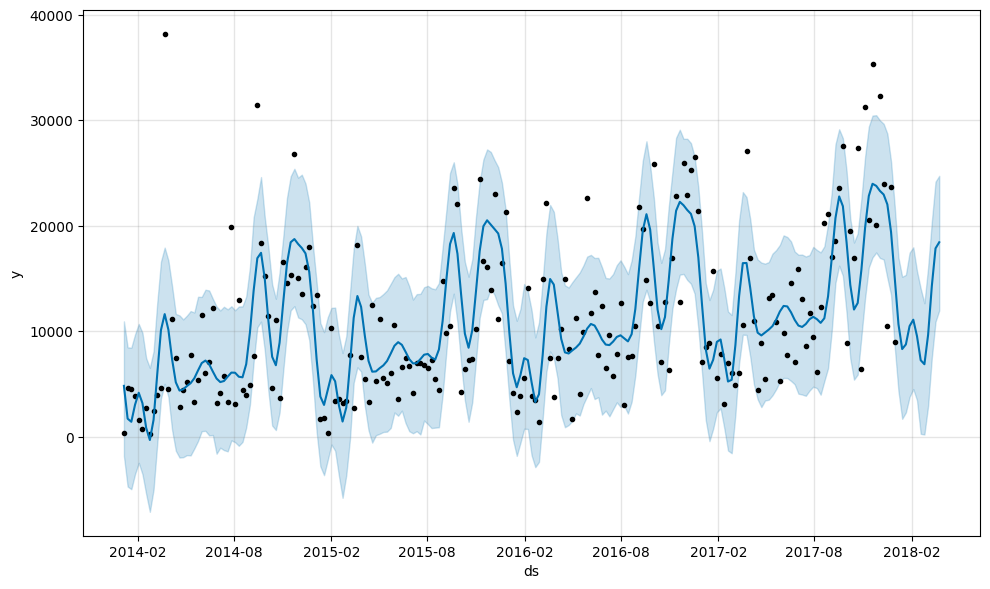

In [38]:
future = model.make_future_dataframe(periods = 12 ,freq = 'W')
forecast = model.predict(future)

model.plot(forecast)
plt.show()

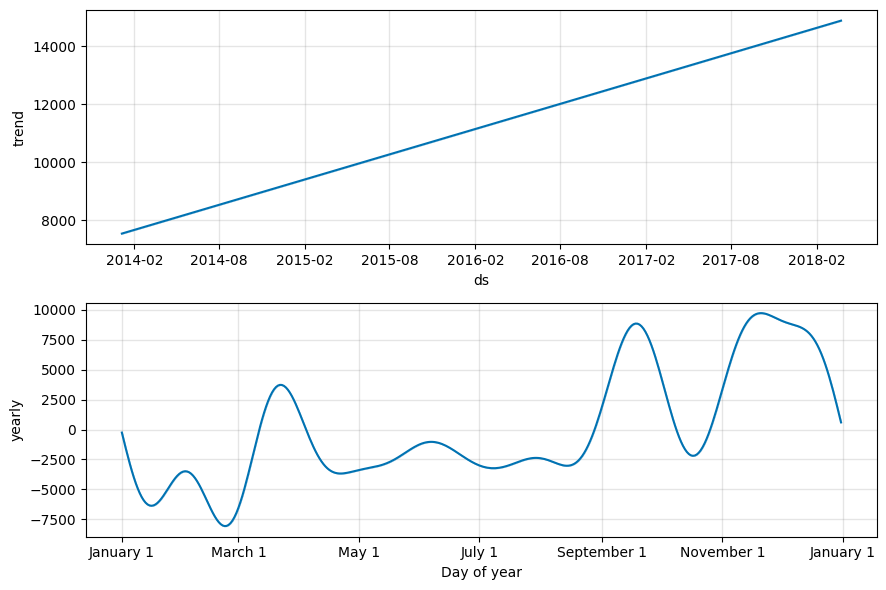

In [39]:
model.plot_components(forecast)
plt.show()

In [61]:
#kiểm tra xem prophet có đúng không
#lấy 8 tuần cuối test , còn đâu dùng train

cutoff = 8

train = df_prophet.iloc[:-cutoff] #train tất cả trừ 8 tuần cuối
test = df_prophet.iloc[-cutoff:] #test 8 tuần cuối

print(f"Train :{len(train)}, Test : {len(test)}")

Train :201, Test : 8


In [62]:
model = Prophet()
model.fit(train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [63]:
future = model.make_future_dataframe(periods = len(test), freq = 'W')
forecast = model.predict(future)


In [64]:
forecast_test = forecast[forecast['ds'].isin(test['ds'])][['ds', 'yhat']]

comparison = test.merge(forecast_test, on='ds')
comparison.columns = ['ds', 'actual', 'predicted']
comparison

,ds,actual,predicted
0,2017-11-12,20571.8720,22189.134835
1,2017-11-19,35344.4230,22523.441834
2,2017-11-26,20087.2490,22037.524015
3,2017-12-03,32354.5700,22175.998823
4,2017-12-10,24006.9580,23024.107246
5,2017-12-17,10495.9630,23050.698031
6,2017-12-24,23662.3640,20595.998413
7,2017-12-31,8977.8318,15747.983980


In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(comparison['actual'], comparison['predicted'])
rmse = np.sqrt(mean_squared_error(comparison['actual'], comparison['predicted']))
mape = np.mean(np.abs((comparison['actual'] - comparison['predicted']) / comparison['actual'])) * 100

print(f"MAE  : {mae:,.0f}")
print(f"RMSE : {rmse:,.0f}")
print(f"MAPE : {mape:.1f}%")

MAE  : 6,243
RMSE : 7,812
MAPE : 37.2%


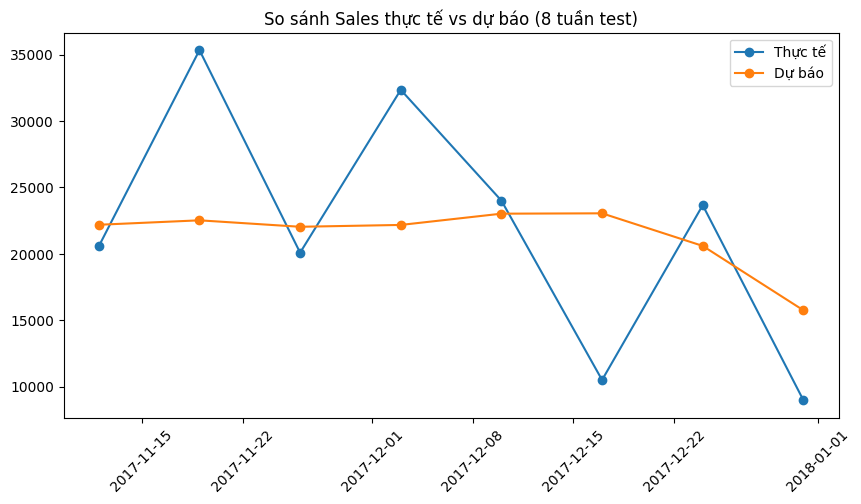

In [66]:
plt.figure(figsize=(10,5))
plt.plot(comparison['ds'], comparison['actual'], label='Thực tế', marker='o')
plt.plot(comparison['ds'], comparison['predicted'], label='Dự báo', marker='o')
plt.legend()
plt.title('So sánh Sales thực tế vs dự báo (8 tuần test)')
plt.xticks(rotation=45)
plt.show()

In [67]:
comparison['error'] = comparison['actual'] - comparison['predicted']
comparison['abs_error'] = comparison['error'].abs()

# Sắp xếp giảm dần theo mức sai lệch tuyệt đối, xem 5 tuần tệ nhất
comparison.sort_values('abs_error', ascending=False).head()

,ds,actual,predicted,error,abs_error
1,2017-11-19,35344.4230,22523.441834,12820.981166,12820.981166
5,2017-12-17,10495.9630,23050.698031,-12554.735031,12554.735031
3,2017-12-03,32354.5700,22175.998823,10178.571177,10178.571177
7,2017-12-31,8977.8318,15747.983980,-6770.152180,6770.152180
6,2017-12-24,23662.3640,20595.998413,3066.365587,3066.365587


In [68]:
model = Prophet()
model.add_country_holidays(country_name='US')   # dạy mô hình biết Thanksgiving, Christmas...
model.fit(train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [69]:
model = Prophet(seasonality_mode='multiplicative')
model.add_country_holidays(country_name='US')
model.fit(train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [70]:
future = model.make_future_dataframe(periods=cutoff, freq='W')
forecast = model.predict(future)

forecast_test = forecast[forecast['ds'].isin(test['ds'])][['ds', 'yhat']]
comparison2 = test.merge(forecast_test, on='ds')
comparison2.columns = ['ds', 'actual', 'predicted']

mae2 = mean_absolute_error(comparison2['actual'], comparison2['predicted'])
rmse2 = np.sqrt(mean_squared_error(comparison2['actual'], comparison2['predicted']))
mape2 = np.mean(np.abs((comparison2['actual'] - comparison2['predicted']) / comparison2['actual'])) * 100

print(f"MAE  : {mae2:,.0f}  (cũ: {mae:,.0f})")
print(f"RMSE : {rmse2:,.0f}  (cũ: {rmse:,.0f})")
print(f"MAPE : {mape2:.1f}%  (cũ: {mape:.1f}%)")

MAE  : 6,397  (cũ: 6,243)
RMSE : 7,829  (cũ: 7,812)
MAPE : 40.6%  (cũ: 37.2%)


In [71]:
print(test['ds'].dt.date.tolist())


[datetime.date(2017, 11, 12), datetime.date(2017, 11, 19), datetime.date(2017, 11, 26), datetime.date(2017, 12, 3), datetime.date(2017, 12, 10), datetime.date(2017, 12, 17), datetime.date(2017, 12, 24), datetime.date(2017, 12, 31)]


In [72]:
def evaluate(model, train, test, periods):
    # huấn luyện mô hình với dữ liệu train
    model.fit(train)

    # tạo các ngày cần dự báo và lấy kết quả dự báo
    future = model.make_future_dataframe(periods=periods, freq='W')
    forecast = model.predict(future)

    # ghép dự báo với số liệu thật để so sánh, giống code cũ
    forecast_test = forecast[forecast['ds'].isin(test['ds'])][['ds', 'yhat']]
    comp = test.merge(forecast_test, on='ds')
    comp.columns = ['ds', 'actual', 'predicted']

    mae = mean_absolute_error(comp['actual'], comp['predicted'])
    rmse = np.sqrt(mean_squared_error(comp['actual'], comp['predicted']))
    mape = np.mean(np.abs((comp['actual'] - comp['predicted']) / comp['actual'])) * 100

    return mae, rmse, mape   # "trả về" 3 con số này để dùng ở ngoài


In [73]:
results = {}

results['Mặc định'] = evaluate(Prophet(), train, test, cutoff)

m1 = Prophet()
m1.add_country_holidays(country_name='US')
results['Chỉ thêm Holidays'] = evaluate(m1, train, test, cutoff)

m2 = Prophet(seasonality_mode='multiplicative')
results['Chỉ đổi Multiplicative'] = evaluate(m2, train, test, cutoff)

m3 = Prophet(seasonality_mode='multiplicative')
m3.add_country_holidays(country_name='US')
results['Cả 2 (như lần trước)'] = evaluate(m3, train, test, cutoff)

print(f"{'Cấu hình':28s}{'MAE':>10s}{'RMSE':>10s}{'MAPE':>8s}")
for name, (mae, rmse, mape) in results.items():
    print(f"{name:28s}{mae:>10,.0f}{rmse:>10,.0f}{mape:>7.1f}%")

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Cấu hình                           MAE      RMSE    MAPE
Mặc định                         6,243     7,812   37.2%
Chỉ thêm Holidays                6,303     7,831   37.8%
Chỉ đổi Multiplicative           6,384     7,819   40.4%
Cả 2 (như lần trước)             6,397     7,829   40.6%


In [74]:
from prophet.diagnostics import cross_validation, performance_metrics

# Train trên toàn bộ dữ liệu trước
m = Prophet()
m.fit(df_prophet)

# initial: dùng 730 ngày (2 năm) đầu tiên để train cho lần test đầu tiên
# period: mỗi 90 ngày lùi lại, lặp lại một lần test mới (test nhiều giai đoạn khác nhau)
# horizon: mỗi lần test, dự báo 56 ngày (= 8 tuần, giống lúc trước) về phía trước
df_cv = cross_validation(m, initial='730 days', period='90 days', horizon='56 days')

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 8 forecasts with cutoffs between 2016-02-14 00:00:00 and 2017-11-05 00:00:00


  0%|          | 0/8 [00:00<?, ?it/s]

In [75]:
df_p = performance_metrics(df_cv)

print(f"MAE trung bình  : {df_p['mae'].mean():,.0f}")
print(f"RMSE trung bình : {df_p['rmse'].mean():,.0f}")
print(f"MAPE trung bình : {df_p['mape'].mean()*100:.1f}%")

MAE trung bình  : 5,402
RMSE trung bình : 6,432
MAPE trung bình : 45.2%
